In [34]:
# !pip install tensorflow
# !pip install kagglehub
# !pip install opencv-python

In [35]:
import tensorflow as tf       # Import Tensorflow library
import numpy as np            # Import Numpy library

In [36]:
mnist = tf.keras.datasets.mnist                            # Load the MNIST dataset (handwritten digits 0-9)
(x_train, y_train), (x_test, y_test) = mnist.load_data()   # Splits into train/test sets
x_train, x_test = x_train / 255.0, x_test / 255.0          # Normalize pixel values from range [0,255] to [0,1]

In [37]:
# Print training dataset information
print("Training Tensors: ")
print("=======================")
print("Parameters: ")
print("1. Number of dimensions in tensor: %d"%x_train.ndim)     # Should be 3D: (samples, height, width)
print("2. Tensor shape: ", x_train.shape)
print("3. Data type: %s"%x_train.dtype)
print("=======================")
print()
# Print testing dataset information
print("Test Tensors: ")
print("=======================")
print("Parameters: ")
print("1. Number of dimensions in tensor: %d"%x_test.ndim)     # Should be 3D: (samples, height, width)
print("2. Tensor shape: ", x_test.shape)
print("3. Data type: %s"%x_test.dtype)

Training Tensors: 
Parameters: 
1. Number of dimensions in tensor: 3
2. Tensor shape:  (60000, 28, 28)
3. Data type: float64

Test Tensors: 
Parameters: 
1. Number of dimensions in tensor: 3
2. Tensor shape:  (10000, 28, 28)
3. Data type: float64


In [38]:
# Build a Sequential neural network model
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),   # Flatten 28x28 image → 784 vector
    tf.keras.layers.Dense(128, activation='relu'),   # Hidden layer with 128 neurons
    tf.keras.layers.Dropout(0.2),                    # Dropout layer to reduce overfitting
    tf.keras.layers.Dense(10, activation='softmax')])  # Output layer for 10 classes (0-9)

# Compile the model
model.compile(
    optimizer='adam',                                # Adam optimizer (better convergence than SGD)
    loss='sparse_categorical_crossentropy',          # Loss function for integer labels
    metrics=['accuracy'])                            # Track accuracy during training

In [39]:
model.fit(x_train, y_train, epochs=5)                # Train the model for 5 epochs
model.evaluate(x_test, y_test, verbose=2)            # Evaluate the model on the test dataset
# Print model architecture and parameter counts
model.summary()

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8593 - loss: 0.4772
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9557 - loss: 0.1502
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9680 - loss: 0.1046
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9724 - loss: 0.0872
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.9772 - loss: 0.0736
313/313 - 2s - 5ms/step - accuracy: 0.9757 - loss: 0.0770


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_7 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,312 (1.16 MB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 203,542 (795.09 KB)

In [7]:
x_test[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [40]:
# Predict probabilities for each class for the given test sample
predictions = model.predict(x_test)
print(predictions[1234])                             # Probability distribution for sample index 1234
np.argmax(predictions[1234])                         # Class with highest probability

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[1.6732638e-04 8.4453968e-05 2.3790142e-02 1.3620064e-02 8.9179766e-06
 6.0545942e-03 7.7728844e-05 1.6079253e-08 9.5606482e-01 1.3181531e-04]


np.int64(8)

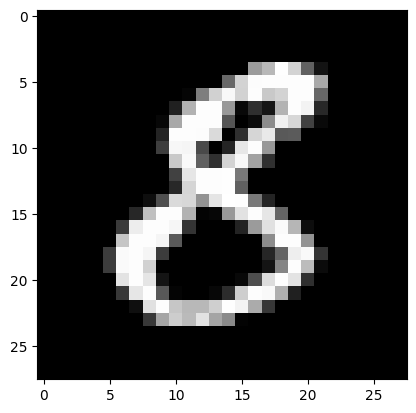

In [41]:
import matplotlib.pyplot as plt
plt.imshow(x_test[1234],cmap='gray')                 # Display the image corresponding to index

In [43]:
# Import additional libraries for Devanagari dataset
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mi
import cv2
import os
import numpy as np
import tensorflow as tf
import kagglehub

# Download Devanagari dataset from Kaggle
dataset_path = kagglehub.dataset_download('medahmedkrichen/devanagari-handwritten-character-datase')
dataset_base_path = os.path.join(dataset_path, 'DevanagariHandwrittenCharacterDataset')
train_path = os.path.join(dataset_base_path, 'Train')
test_path = os.path.join(dataset_base_path, 'Test')

# Load the training dataset into TensorFlow format
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels='inferred',               # Infer labels from folder names
    label_mode='int',                 # Integer labels
    image_size=(28, 28),               # Resize to 28x28 for compatibility with MNIST model
    interpolation='nearest',
    batch_size=32,
    shuffle=False)
# Load the testing dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    labels='inferred',
    label_mode='int',
    image_size=(28, 28),
    interpolation='nearest',
    batch_size=32,
    shuffle=False)

# Convert TensorFlow datasets to NumPy arrays
x_train = np.concatenate([x for x, y in train_ds], axis=0)
y_train = np.concatenate([y for x, y in train_ds], axis=0)
x_test = np.concatenate([x for x, y in test_ds], axis=0)
y_test = np.concatenate([y for x, y in test_ds], axis=0)
# Convert images to grayscale by taking the mean across the color channels
x_train = np.mean(x_train, axis=-1, keepdims=True)
x_test = np.mean(x_test, axis=-1, keepdims=True)
x_train, x_test = x_train / 255.0, x_test / 255.0      # Normalize pixel values to [0,1]

# Print dataset shapes
print("Devanagari dataset loaded and preprocessed.")
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

path = kagglehub.dataset_download("medahmedkrichen/devanagari-handwritten-character-datase")
print("Path to dataset files:", path)

Found 78200 files belonging to 46 classes.
Found 13800 files belonging to 46 classes.
Devanagari dataset loaded and preprocessed.
x_train shape: (78200, 28, 28, 1)
y_train shape: (78200,)
x_test shape: (13800, 28, 28, 1)
y_test shape: (13800,)
Path to dataset files: /kaggle/input/devanagari-handwritten-character-datase


In [44]:
x_test[0]

array([[[0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ]],

       [[0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        

In [45]:
"""
predictions = model.predict(x_test)
print(predictions[5678])
print(type(predictions))
np.argmax(predictions[5678])
"""

'\npredictions = model.predict(x_test)\nprint(predictions[5678])\nprint(type(predictions))\nnp.argmax(predictions[5678])\n'

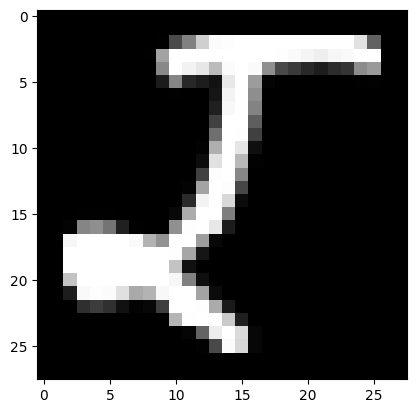

In [46]:
plt.imshow(x_test[5678],cmap='gray')          # Will display the image according to index

In [47]:
pred=[]                                       # Generate predicted class labels for the entire test set
for j in range(len(predictions)):
   pred.append(np.argmax(predictions[j]))     # Convert probabilities to class index

In [48]:
pred

[np.int64(7),
 np.int64(2),
 np.int64(1),
 np.int64(0),
 np.int64(4),
 np.int64(1),
 np.int64(4),
 np.int64(9),
 np.int64(5),
 np.int64(9),
 np.int64(0),
 np.int64(6),
 np.int64(9),
 np.int64(0),
 np.int64(1),
 np.int64(5),
 np.int64(9),
 np.int64(7),
 np.int64(3),
 np.int64(4),
 np.int64(9),
 np.int64(6),
 np.int64(6),
 np.int64(5),
 np.int64(4),
 np.int64(0),
 np.int64(7),
 np.int64(4),
 np.int64(0),
 np.int64(1),
 np.int64(3),
 np.int64(1),
 np.int64(3),
 np.int64(4),
 np.int64(7),
 np.int64(2),
 np.int64(7),
 np.int64(1),
 np.int64(2),
 np.int64(1),
 np.int64(1),
 np.int64(7),
 np.int64(4),
 np.int64(2),
 np.int64(3),
 np.int64(5),
 np.int64(1),
 np.int64(2),
 np.int64(4),
 np.int64(4),
 np.int64(6),
 np.int64(3),
 np.int64(5),
 np.int64(5),
 np.int64(6),
 np.int64(0),
 np.int64(4),
 np.int64(1),
 np.int64(9),
 np.int64(5),
 np.int64(7),
 np.int64(8),
 np.int64(9),
 np.int64(3),
 np.int64(7),
 np.int64(4),
 np.int64(6),
 np.int64(4),
 np.int64(3),
 np.int64(0),
 np.int64(7),
 np.in

In [49]:
class_names = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

Epoch 1/5
2444/2444 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 0.5130 - loss: 1.8348
Epoch 2/5
2444/2444 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.7645 - loss: 0.8259
Epoch 3/5
2444/2444 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.8134 - loss: 0.6443
Epoch 4/5
2444/2444 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.8390 - loss: 0.5569
Epoch 5/5
2444/2444 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.8499 - loss: 0.5019
432/432 - 1s - 3ms/step - accuracy: 0.8907 - loss: 0.3793
432/432 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Confusion Matrix (Devanagari):
[[275   0   0 ...   0   0   1]
 [  0 271   2 ...   0  13   0]
 [  0   1 283 ...   0   0   0]
 ...
 [  0   0   0 ... 295   0   0]
 [  0   2   0 ...   0 294   0]
 [  0   0   0 ...   0   1 292]]


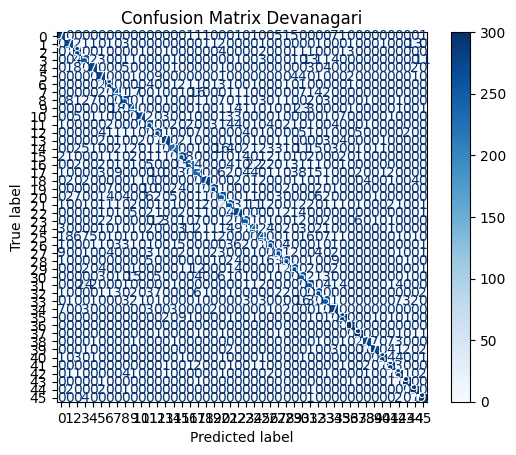

In [50]:
import sklearn
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
# Rebuild/retrain model if separate from MNIST
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(len(np.unique(y_train)), activation='softmax')])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=5)
model.evaluate(x_test, y_test, verbose=2)

predictions = model.predict(x_test)       # Predictions + metrics (Devanagari)
pred = np.argmax(predictions, axis=1)
cm = confusion_matrix(y_test, pred)
print("Confusion Matrix (Devanagari):")
print(cm)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix Devanagari")
plt.show()

In [51]:
from sklearn.metrics import classification_report
print("Classification Report (Devanagari):")
print(classification_report(y_test,pred))

Classification Report (Devanagari):
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       300
           1       0.91      0.90      0.91       300
           2       0.87      0.94      0.91       300
           3       0.83      0.84      0.83       300
           4       0.92      0.92      0.92       300
           5       0.88      0.92      0.90       300
           6       0.92      0.93      0.93       300
           7       0.85      0.82      0.83       300
           8       0.90      0.86      0.88       300
           9       0.81      0.81      0.81       300
          10       0.97      0.90      0.94       300
          11       0.85      0.89      0.87       300
          12       0.83      0.88      0.86       300
          13       0.95      0.93      0.94       300
          14       0.92      0.76      0.84       300
          15       0.84      0.88      0.86       300
          16       0.89      0.77      0.83  

In [52]:
# Overall metrics
print('Accuracy:', sklearn.metrics.accuracy_score(y_test,pred))
print('F1 score:',sklearn.metrics.f1_score(y_test,pred, average='weighted'))
print('Recall:',sklearn.metrics.recall_score(y_test,pred, average='weighted'))
print('Precision:',sklearn.metrics.precision_score(y_test,pred, average='weighted'))

Accuracy: 0.8906521739130435
F1 score: 0.8906120209718416
Recall: 0.8906521739130435
Precision: 0.8920730189433369
